In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/"


'Colab Notebooks'


In [ ]:
!find /content/drive/MyDrive/ -name "mbti_1.csv"


/content/drive/MyDrive/Colab Notebooks/mbti project/mbti_1.csv


In [ ]:
import pandas as pd
df = pd.read_csv("mbti_1.csv")
print(df.shape)
print(df.head())


(8675, 2)
   type                                              posts
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1  ENTP  'I'm finding the lack of me in these posts ver...
2  INTP  'Good one  _____   https://www.youtube.com/wat...
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...
4  ENTJ  'You're fired.|||That's another silly misconce...


In [ ]:
print(df['type'].value_counts())


type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64


In [ ]:
import re, nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)   # remove urls
    text = re.sub(r"[^a-zA-Z\s]", "", text)               # remove punctuation/numbers
    text = text.lower()                                   # lowercase
    return " ".join([word for word in text.split() if word not in stop_words])

df['clean_posts'] = df['posts'].apply(clean_text)
print(df[['posts','clean_posts']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                               posts  \
0  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...   
1  'I'm finding the lack of me in these posts ver...   
2  'Good one  _____   https://www.youtube.com/wat...   
3  'Dear INTP,   I enjoyed our conversation the o...   
4  'You're fired.|||That's another silly misconce...   

                                         clean_posts  
0  intj moments sportscenter top ten plays pranks...  
1  im finding lack posts alarmingsex boring posit...  
2  good one course say know thats blessing cursed...  
3  dear intp enjoyed conversation day esoteric ga...  
4  youre firedthats another silly misconception a...  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_posts'])
y = df['type']


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        ENFJ       0.56      0.12      0.20        41
        ENFP       0.71      0.58      0.64       125
        ENTJ       0.79      0.34      0.48        44
        ENTP       0.67      0.52      0.59       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       1.00      0.13      0.24        15
        INFJ       0.64      0.68      0.66       288
        INFP       0.60      0.85      0.70       370
        INTJ       0.62      0.70      0.66       193
        INTP       0.63      0.79      0.70       293
        ISFJ       0.91      0.22      0.36        45
        ISFP       0.69      0.21      0.32        53
        ISTJ       0.71      0.23      0.34        44
        ISTP       0.71      0.37      0.49        67

    accuracy                           0.63      1735
   macro avg       0.58   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)


In [ ]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer('all-MiniLM-L6-v2')
X_embed = sbert.encode(df['clean_posts'], show_progress_bar=True)


Batches:   0%|          | 0/272 [00:00<?, ?it/s]

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# Encode MBTI types into numbers
le = LabelEncoder()
y_encoded = le.fit_transform(df['type'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_embed, y_encoded, test_size=0.2, random_state=42)

# Train XGBoost classifier
xgb = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Decode labels back
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

# Report
print(classification_report(y_test_labels, y_pred_labels))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:56:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        41
        ENFP       0.20      0.08      0.11       125
        ENTJ       0.00      0.00      0.00        44
        ENTP       0.19      0.10      0.13       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       1.00      0.07      0.12        15
        INFJ       0.28      0.35      0.31       288
        INFP       0.37      0.64      0.47       370
        INTJ       0.17      0.21      0.19       193
        INTP       0.32      0.38      0.35       293
        ISFJ       0.00      0.00      0.00        45
        ISFP       0.00      0.00      0.00        53
        ISTJ       0.00      0.00      0.00        44
        ISTP       0.46      0.09      0.15        67

    accuracy                           0.30      1735
   macro avg       0.19   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_embed, y_encoded)
print(X_res.shape, y_res.shape)


(29312, 384) (29312,)


In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.37      0.20      0.26       125
           2       0.00      0.00      0.00        44
           3       0.38      0.21      0.27       135
           4       0.00      0.00      0.00         7
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00        15
           8       0.33      0.43      0.37       288
           9       0.41      0.69      0.51       370
          10       0.23      0.23      0.23       193
          11       0.38      0.48      0.43       293
          12       0.00      0.00      0.00        45
          13       0.00      0.00      0.00        53
          14       0.00      0.00      0.00        44
          15       0.42      0.07      0.13        67

    accuracy                           0.36      1735
   macro avg       0.16   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
xgb = XGBClassifier(
    n_estimators=100,   # pehle kam trees rakho
    max_depth=5,        # shallow trees
    learning_rate=0.1,
    tree_method='hist', # fast histogram method
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Train model
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Decode predictions back to labels (optional)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

# Report
from sklearn.metrics import classification_report
print(classification_report(y_test_labels, y_pred_labels))


              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        41
        ENFP       0.27      0.10      0.14       125
        ENTJ       0.00      0.00      0.00        44
        ENTP       0.18      0.07      0.10       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       1.00      0.07      0.12        15
        INFJ       0.28      0.36      0.31       288
        INFP       0.38      0.68      0.49       370
        INTJ       0.19      0.22      0.20       193
        INTP       0.34      0.40      0.37       293
        ISFJ       0.00      0.00      0.00        45
        ISFP       0.00      0.00      0.00        53
        ISTJ       0.00      0.00      0.00        44
        ISTP       0.70      0.10      0.18        67

    accuracy                           0.31      1735
   macro avg       0.21   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
df_small = df.sample(2000, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.59      0.62      0.60       376
           1       0.53      0.41      0.46       360
           2       0.56      0.67      0.61       401
           3       0.47      0.47      0.47       344
           4       0.85      0.94      0.89       382
           5       0.72      0.94      0.82       371
           6       0.80      0.95      0.87       351
           7       0.76      0.82      0.79       391
           8       0.38      0.26      0.31       360
           9       0.36      0.28      0.31       345
          10       0.39      0.23      0.29       379
          11       0.38      0.36      0.37       344
          12       0.59      0.69      0.64       350
          13       0.58      0.60      0.59       387
          14       0.55      0.59      0.57       353
          15       0.58      0.58      0.58       369

    accuracy                           0.59      5863
   macro avg       0.57   

In [ ]:
xgb = XGBClassifier(
    n_estimators=50,   # kam trees
    max_depth=4,       # shallow depth
    learning_rate=0.2, # fast training
    tree_method='hist',
    eval_metric='mlogloss'
)


In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    tree_method='gpu_hist',   # GPU mode
    eval_metric='mlogloss'
)


In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    tree_method='hist',   # fast CPU histogram mode
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.94      0.92       376
           1       0.76      0.74      0.75       360
           2       0.84      0.94      0.89       401
           3       0.77      0.78      0.78       344
           4       0.98      1.00      0.99       382
           5       0.99      1.00      0.99       371
           6       0.98      1.00      0.99       351
           7       0.97      0.99      0.98       391
           8       0.51      0.44      0.47       360
           9       0.46      0.42      0.44       345
          10       0.65      0.54      0.59       379
          11       0.53      0.54      0.53       344
          12       0.94      0.97      0.95       350
          13       0.90      0.92      0.91       387
          14       0.89      0.91      0.90       353
          15       0.85      0.91      0.88       369

    accuracy                           0.82      5863
   macro avg       0.81   

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mbti_1.csv to mbti_1.csv


In [ ]:
import pandas as pd
df = pd.read_csv("mbti_1.csv")


In [ ]:
import pandas as pd

# yaha apna exact file name likhna jo upload ke baad dikh raha hai
df = pd.read_csv("mbti_1.csv")

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (8675, 2)
   type                                              posts
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1  ENTP  'I'm finding the lack of me in these posts ver...
2  INTP  'Good one  _____   https://www.youtube.com/wat...
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...
4  ENTJ  'You're fired.|||That's another silly misconce...


In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load dataset
df = pd.read_csv("mbti_1.csv")   # <-- apna dataset ka naam yahan do
print(df.head())

# 2. Preprocessing (example: assuming dataset has columns 'type' (label) and 'posts' (text))
X = df['posts']
y = df['type']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 5. Model 1: Support Vector Machine
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

print("\n🔹 SVM Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# 6. Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

print("\n🔹 Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


   type                                              posts
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1  ENTP  'I'm finding the lack of me in these posts ver...
2  INTP  'Good one  _____   https://www.youtube.com/wat...
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...
4  ENTJ  'You're fired.|||That's another silly misconce...

🔹 SVM Performance:
Accuracy: 0.659942363112392
              precision    recall  f1-score   support

        ENFJ       0.63      0.29      0.40        41
        ENFP       0.65      0.63      0.64       125
        ENTJ       0.66      0.48      0.55        44
        ENTP       0.68      0.61      0.64       135
        ESFJ       0.33      0.14      0.20         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.60      0.43      0.50         7
        ESTP       0.86      0.40      0.55        15
        INFJ       0.64      0.65      0.65       288
        INFP       0.68      0.79      0.73       370
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🔹 Baseline Performance (CountVec + Logistic Regression):
Accuracy: 0.6213256484149856
              precision    recall  f1-score   support

        ENFJ       0.53      0.24      0.33        41
        ENFP       0.58      0.58      0.58       125
        ENTJ       0.58      0.50      0.54        44
        ENTP       0.65      0.56      0.60       135
        ESFJ       0.50      0.14      0.22         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.43      0.43      0.43         7
        ESTP       0.60      0.40      0.48        15
        INFJ       0.59      0.62      0.61       288
        INFP       0.67      0.73      0.70       370
        INTJ       0.55      0.67      0.61       193
        INTP       0.65      0.72      0.68       293
        ISFJ       0.81      0.49      0.61        45
        ISFP       0.60      0.45      0.52        53
        ISTJ       0.62      0.45      0.53        44
        ISTP       0.65      0.51      0.57     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


🔹 Random Forest Performance (TF-IDF):
Accuracy: 0.579250720461095
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        41
        ENFP       0.79      0.40      0.53       125
        ENTJ       0.40      0.05      0.08        44
        ENTP       0.72      0.44      0.54       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       0.00      0.00      0.00        15
        INFJ       0.57      0.70      0.63       288
        INFP       0.49      0.89      0.63       370
        INTJ       0.61      0.62      0.61       193
        INTP       0.67      0.75      0.71       293
        ISFJ       1.00      0.02      0.04        45
        ISFP       0.50      0.04      0.07        53
        ISTJ       0.50      0.02      0.04        44
        ISTP       0.88      0.31      0.46        67

    accuracy 

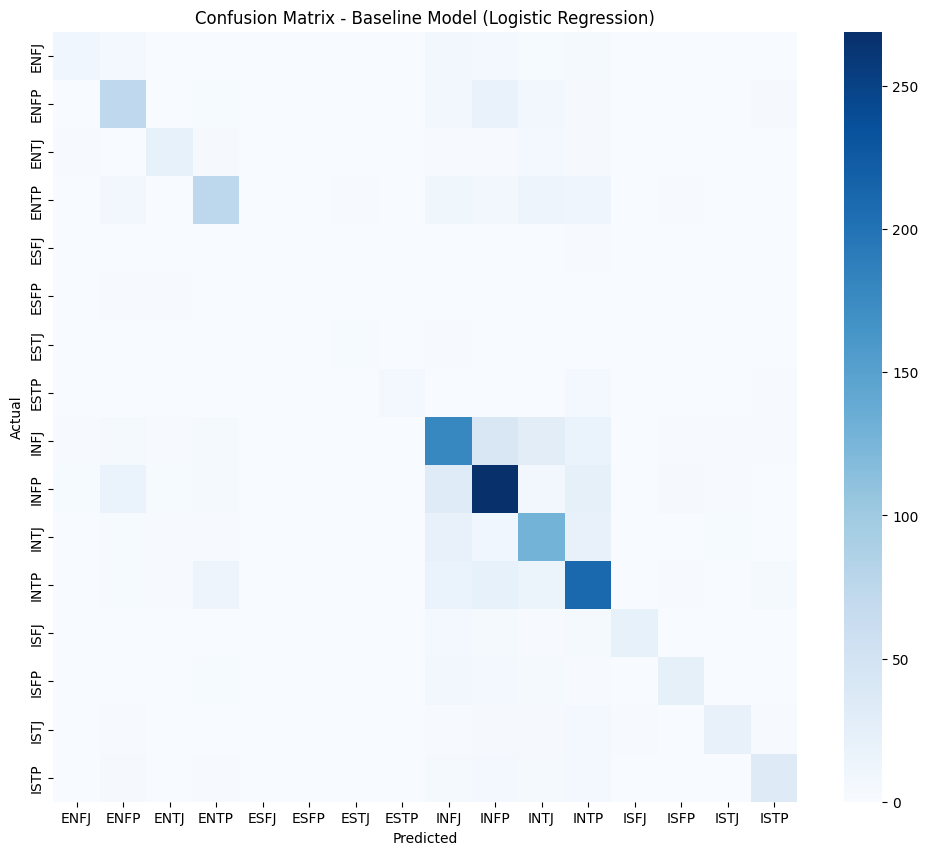

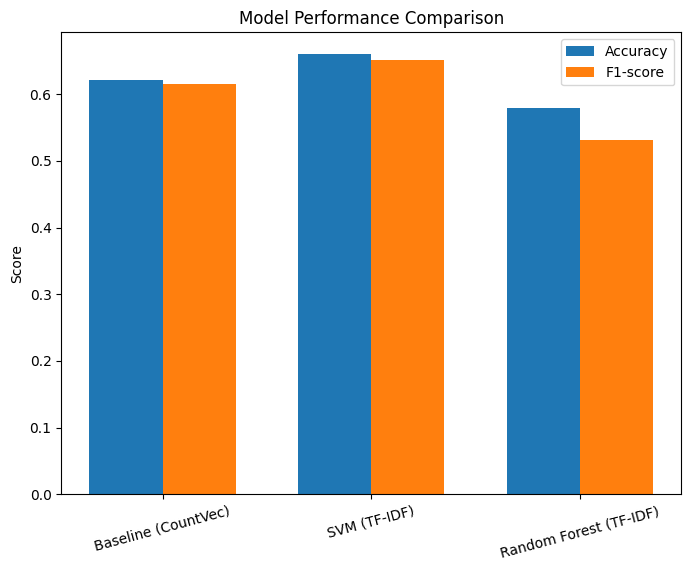

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load dataset
df = pd.read_csv("mbti_1.csv")
X = df['posts']
y = df['type']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# Baseline Model: CountVec + Logistic Regression
# -------------------------------
count_vec = CountVectorizer(stop_words='english', max_features=5000)
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv = count_vec.transform(X_test)

baseline = LogisticRegression(max_iter=2000)
baseline.fit(X_train_cv, y_train)
y_pred_baseline = baseline.predict(X_test_cv)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_report = classification_report(y_test, y_pred_baseline, output_dict=True)
baseline_f1 = baseline_report['weighted avg']['f1-score']

print("\n🔹 Baseline Performance (CountVec + Logistic Regression):")
print("Accuracy:", baseline_acc)
print(classification_report(y_test, y_pred_baseline))

# -------------------------------
# Model 2: SVM (TF-IDF)
# -------------------------------
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
svm_f1 = svm_report['weighted avg']['f1-score']

print("\n🔹 SVM Performance (TF-IDF):")
print("Accuracy:", svm_acc)
print(classification_report(y_test, y_pred_svm))

# -------------------------------
# Model 3: Random Forest (TF-IDF)
# -------------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
rf_f1 = rf_report['weighted avg']['f1-score']

print("\n🔹 Random Forest Performance (TF-IDF):")
print("Accuracy:", rf_acc)
print(classification_report(y_test, y_pred_rf))

# -------------------------------
# Visualization 1: Confusion Matrix (Baseline Example)
# -------------------------------
cm = confusion_matrix(y_test, y_pred_baseline, labels=baseline.classes_)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=baseline.classes_, yticklabels=baseline.classes_)
plt.title("Confusion Matrix - Baseline Model (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# Visualization 2: Bar Chart for Accuracy & F1 Comparison
# -------------------------------
models = ["Baseline (CountVec)", "SVM (TF-IDF)", "Random Forest (TF-IDF)"]
accuracy = [baseline_acc, svm_acc, rf_acc]
f1 = [baseline_f1, svm_f1, rf_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy')
rects2 = ax.bar(x + width/2, f1, width, label='F1-score')

ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.show()


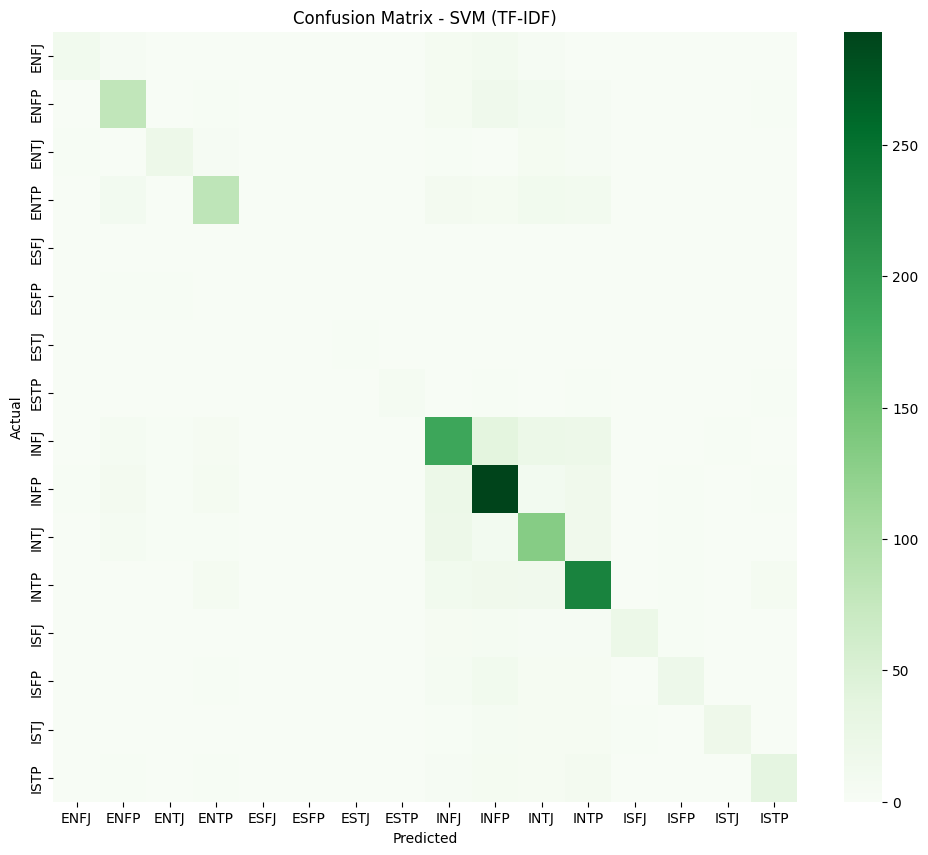

/tmp/ipython-input-993515622.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=svm.classes_, y=svm_f1_scores, palette="viridis")


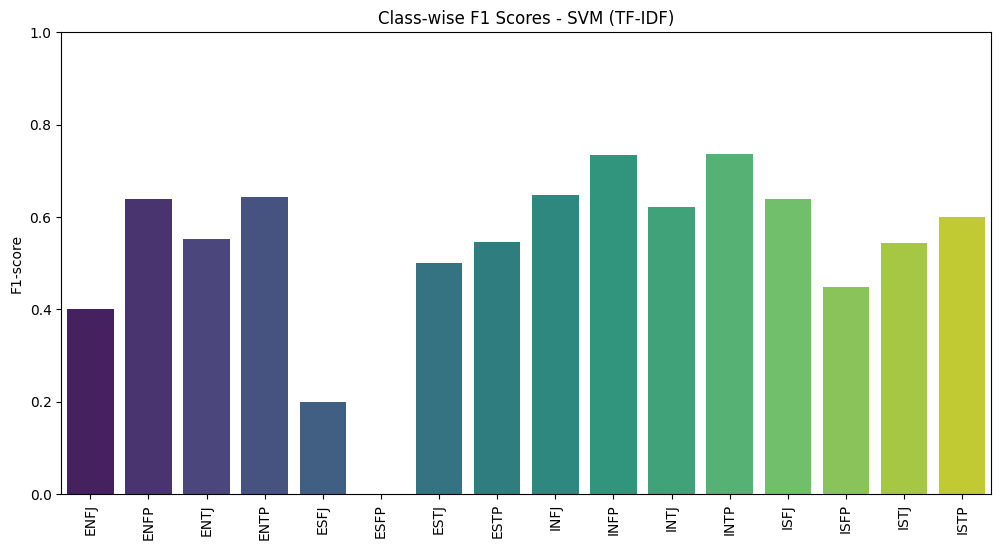

In [ ]:
# 🔹 1. Confusion Matrix for SVM (TF-IDF)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)

plt.figure(figsize=(12,10))
sns.heatmap(cm_svm, annot=False, fmt="d", cmap="Greens",
            xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.title("Confusion Matrix - SVM (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 🔹 2. Class-wise F1-score Bar Plot (SVM)
# classification_report dictionary se f1-scores nikalna
from sklearn.metrics import classification_report

svm_report_dict = classification_report(y_test, y_pred_svm, output_dict=True)

svm_f1_scores = [svm_report_dict[str(label)]['f1-score'] for label in svm.classes_]

plt.figure(figsize=(12,6))
sns.barplot(x=svm.classes_, y=svm_f1_scores, palette="viridis")
plt.title("Class-wise F1 Scores - SVM (TF-IDF)")
plt.xticks(rotation=90)
plt.ylabel("F1-score")
plt.ylim(0,1)  # 0 to 1 scale for clarity
plt.show()


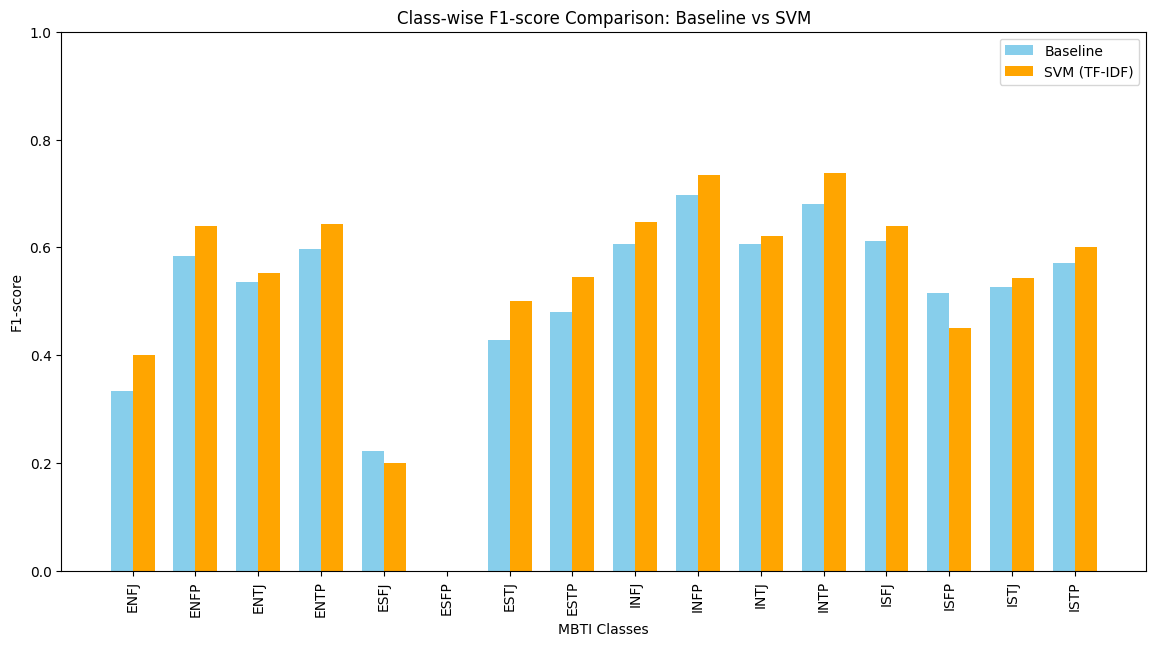

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Baseline report dictionary
baseline_report_dict = classification_report(y_test, y_pred_baseline, output_dict=True)
baseline_f1_scores = [baseline_report_dict[str(label)]['f1-score'] for label in baseline.classes_]

# 🔹 SVM report dictionary (already calculated)
svm_report_dict = classification_report(y_test, y_pred_svm, output_dict=True)
svm_f1_scores = [svm_report_dict[str(label)]['f1-score'] for label in svm.classes_]

# 🔹 Plotting side-by-side bar chart
x = np.arange(len(baseline.classes_))  # class labels as x-axis
width = 0.35  # width of bars

plt.figure(figsize=(14,7))
plt.bar(x - width/2, baseline_f1_scores, width, label="Baseline", color="skyblue")
plt.bar(x + width/2, svm_f1_scores, width, label="SVM (TF-IDF)", color="orange")

plt.xticks(x, baseline.classes_, rotation=90)
plt.xlabel("MBTI Classes")
plt.ylabel("F1-score")
plt.title("Class-wise F1-score Comparison: Baseline vs SVM")
plt.legend()
plt.ylim(0,1)  # scale 0 to 1
plt.show()


**Deep Learning Models**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving mbti_1.csv to mbti_1.csv


In [ ]:
import pandas as pd
df = pd.read_csv("mbti_1.csv")
print(df.shape)


(8675, 2)


In [ ]:
import re

def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # remove links
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove non-letters
    return text.lower()

df['clean_posts'] = df['posts'].apply(clean_text)
print(df[['type','clean_posts']].head())


   type                                        clean_posts
0  INFJ   and intj moments    sportscenter not top ten ...
1  ENTP  im finding the lack of me in these posts very ...
2  INTP  good one      course to which i say i know tha...
3  INTJ  dear intp   i enjoyed our conversation the oth...
4  ENTJ  youre firedthats another silly misconception t...


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

MAX_VOCAB = 20000   # top words to keep
MAX_LEN = 200       # max words per post

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_posts'])

X_seq = tokenizer.texts_to_sequences(df['clean_posts'])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post')

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['type'])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_encoded, test_size=0.2, random_state=42)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

EMB_DIM = 128
NUM_CLASSES = len(le.classes_)

model_bilstm = Sequential([
    Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_bilstm.compile(loss='sparse_categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

history_bilstm = model_bilstm.fit(X_train, y_train,
                                  validation_data=(X_test, y_test),
                                  epochs=5,
                                  batch_size=64)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.1649 - loss: 2.5265 - val_accuracy: 0.2133 - val_loss: 2.2928
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.1937 - loss: 2.3010 - val_accuracy: 0.2161 - val_loss: 2.2750
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.2246 - loss: 2.1382 - val_accuracy: 0.2184 - val_loss: 2.3371
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.3536 - loss: 1.7972 - val_accuracy: 0.1994 - val_loss: 2.5803
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5610 - loss: 1.2992 - val_accuracy: 0.1948 - val_loss: 2.8772


In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

model_cnn = Sequential([
    Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model_cnn.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_cnn = model_cnn.fit(X_train, y_train,
                            validation_data=(X_test, y_test),
                            epochs=5,
                            batch_size=64)


Epoch 1/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 191ms/step - accuracy: 0.2073 - loss: 2.4653 - val_accuracy: 0.2127 - val_loss: 2.2592
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 191ms/step - accuracy: 0.2490 - loss: 2.2282 - val_accuracy: 0.3349 - val_loss: 2.1047
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.3768 - loss: 2.0385 - val_accuracy: 0.3746 - val_loss: 2.0125
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.4299 - loss: 1.9086 - val_accuracy: 0.3988 - val_loss: 1.9714
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 40s 198ms/step - accuracy: 0.5325 - loss: 1.6601 - val_accuracy: 0.3937 - val_loss: 1.9507


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Bi-LSTM predictions
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test), axis=1)
print("\n🔹 Bi-LSTM Performance")
print(classification_report(y_test, y_pred_bilstm, target_names=le.classes_))

# CNN predictions
y_pred_cnn = np.argmax(model_cnn.predict(X_test), axis=1)
print("\n🔹 CNN Performance")
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))


55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/step

🔹 Bi-LSTM Performance
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        41
        ENFP       0.10      0.19      0.13       125
        ENTJ       0.06      0.02      0.03        44
        ENTP       0.10      0.12      0.11       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       0.00      0.00      0.00        15
        INFJ       0.20      0.31      0.24       288
        INFP       0.31      0.27      0.29       370
        INTJ       0.16      0.12      0.14       193
        INTP       0.25      0.27      0.26       293
        ISFJ       0.00      0.00      0.00        45
        ISFP       0.03      0.02      0.02        53
        ISTJ       0.00      0.00      0.00        44
        ISTP       0.10      0.04      0.06        67

    accuracy   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

🔹 CNN Performance
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        41
        ENFP       0.41      0.35      0.38       125
        ENTJ       0.00      0.00      0.00        44
        ENTP       0.41      0.30      0.35       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       0.00      0.00      0.00        15
        INFJ       0.28      0.61      0.39       288
        INFP       0.41      0.62      0.50       370
        INTJ       0.46      0.40      0.43       193
        INTP       0.61      0.37      0.46       293
        ISFJ       0.00      0.00      0.00        45
        ISFP       0.00      0.00      0.00        53
        ISTJ       0.00      0.00      0.00        44
        ISTP       0.73      0.12      0.21        67

    accuracy         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Bi-LSTM Accuracy
bilstm_acc = accuracy_score(y_test, y_pred_bilstm)

# CNN Accuracy
bilstm_acc = round(bilstm_acc*100, 2)
cnn_acc = round(accuracy_score(y_test, y_pred_cnn)*100, 2)

# Comparison Table
dl_results = pd.DataFrame({
    "Model": ["Bi-LSTM (Random Embedding)", "CNN (Random Embedding)"],
    "Accuracy (%)": [bilstm_acc, cnn_acc]
})

print("\n🔹 Deep Learning Model Comparison")
print(dl_results)



🔹 Deep Learning Model Comparison
                        Model  Accuracy (%)
0  Bi-LSTM (Random Embedding)         19.48
1      CNN (Random Embedding)         39.37


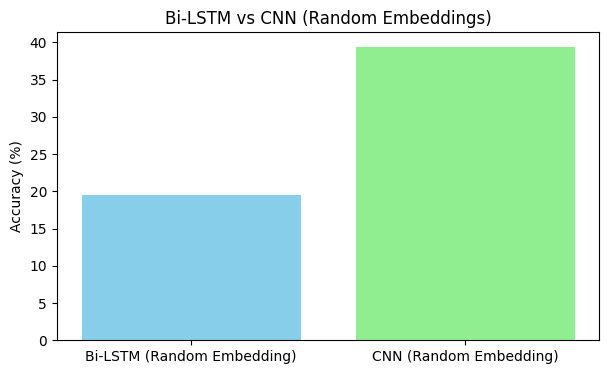

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(dl_results["Model"], dl_results["Accuracy (%)"], color=["skyblue","lightgreen"])
plt.ylabel("Accuracy (%)")
plt.title("Bi-LSTM vs CNN (Random Embeddings)")
plt.show()


In [ ]:
# Download Glove embeddings (100d vectors)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

# Load embeddings into dictionary
import numpy as np
embeddings_index = {}
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coeffs

print("Loaded word vectors:", len(embeddings_index))


--2025-09-09 15:56:45--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-09-09 15:56:45--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-09-09 15:56:45--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
EMB_DIM = 100  # matching glove.6B.100d.txt

embedding_matrix = np.zeros((MAX_VOCAB, EMB_DIM))
for word, i in tokenizer.word_index.items():
    if i < MAX_VOCAB:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

NUM_CLASSES = len(le.classes_)

model_glove_bilstm = Sequential([
    Embedding(MAX_VOCAB, EMB_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_glove_bilstm.compile(loss='sparse_categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

history_glove_bilstm = model_glove_bilstm.fit(X_train, y_train,
                                              validation_data=(X_test, y_test),
                                              epochs=5,
                                              batch_size=64)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


109/109 ━━━━━━━━━━━━━━━━━━━━ 110s 952ms/step - accuracy: 0.1553 - loss: 2.4813 - val_accuracy: 0.2144 - val_loss: 2.2904
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 137s 916ms/step - accuracy: 0.1816 - loss: 2.3548 - val_accuracy: 0.2133 - val_loss: 2.2854
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 146s 952ms/step - accuracy: 0.2010 - loss: 2.3183 - val_accuracy: 0.2133 - val_loss: 2.2805
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.2039 - loss: 2.3094 - val_accuracy: 0.2219 - val_loss: 2.2700
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 123s 881ms/step - accuracy: 0.2139 - loss: 2.2940 - val_accuracy: 0.2196 - val_loss: 2.2918


In [ ]:
from sklearn.metrics import classification_report

y_pred_glove_bilstm = np.argmax(model_glove_bilstm.predict(X_test), axis=1)

print("\n🔹 Bi-LSTM (Glove Embedding) Performance")
print(classification_report(y_test, y_pred_glove_bilstm, target_names=le.classes_))


55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step

🔹 Bi-LSTM (Glove Embedding) Performance
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        41
        ENFP       0.00      0.00      0.00       125
        ENTJ       0.00      0.00      0.00        44
        ENTP       0.00      0.00      0.00       135
        ESFJ       0.00      0.00      0.00         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       0.00      0.00      0.00        15
        INFJ       0.00      0.00      0.00       288
        INFP       0.22      0.94      0.35       370
        INTJ       0.27      0.02      0.04       193
        INTP       0.25      0.11      0.15       293
        ISFJ       0.00      0.00      0.00        45
        ISFP       0.00      0.00      0.00        53
        ISTJ       0.00      0.00      0.00        44
        ISTP       0.00      0.00      0.00        6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd

df = pd.read_csv('mbti_1.csv')

# Saare column names print karo
print(df.columns.tolist())


['type', 'posts']


In [ ]:
import pandas as pd

# CSV load karo
df = pd.read_csv('mbti_1.csv')

# Texts aur labels
texts = df['posts'].astype(str).tolist()
labels = df['type'].tolist()


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
max_len = 100  # adjust as needed
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Vocabulary size
vocab_size = min(max_words, len(tokenizer.word_index) + 1)


In [ ]:
# ===== 1️⃣ Import Libraries =====
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ===== 2️⃣ Load Dataset =====
df = pd.read_csv('mbti_1.csv')  # CSV path change karo
df.columns = df.columns.str.strip()   # Extra spaces remove

texts = df['posts'].astype(str).tolist()
labels = df['type'].tolist()

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(texts, labels_encoded, test_size=0.2, random_state=42)

# ===== 3️⃣ Tokenizer + Padding =====
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

vocab_size = min(max_words, len(tokenizer.word_index) + 1)

# ===== 4️⃣ Load GloVe Embeddings =====
embedding_dim = 100
embedding_index = {}

# Make sure you've uploaded glove.6B.100d.txt in Colab
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# ===== 5️⃣ Build BiLSTM Model =====
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    input_length=max_len,
                    trainable=False))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

# ===== 6️⃣ Compile Model =====
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===== 7️⃣ Train Model =====
history = model.fit(X_train_pad, np.array(y_train),
                    validation_data=(X_test_pad, np.array(y_test)),
                    epochs=10, batch_size=32)

# ===== 8️⃣ Evaluate =====
loss, acc = model.evaluate(X_test_pad, np.array(y_test))
print(f"Test Accuracy: {acc*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 61s 239ms/step - accuracy: 0.1752 - loss: 2.3897 - val_accuracy: 0.2133 - val_loss: 2.2829
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 50s 229ms/step - accuracy: 0.2114 - loss: 2.3064 - val_accuracy: 0.2173 - val_loss: 2.2762
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 49s 227ms/step - accuracy: 0.2128 - loss: 2.2916 - val_accuracy: 0.2236 - val_loss: 2.2683
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 50s 229ms/step - accuracy: 0.2173 - loss: 2.2669 - val_accuracy: 0.2213 - val_loss: 2.2582
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 81s 226ms/step - accuracy: 0.2243 - loss: 2.2572 - val_accuracy: 0.2167 - val_loss: 2.2637
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 84s 237ms/step - accuracy: 0.2363 - loss: 2.2217 - val_accuracy: 0.2225 - val_loss: 2.2460
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 80s 230ms/step - accuracy: 0.2479 - loss: 2.2013 - val_accuracy: 0.2294 - val_loss: 2.2458
Epoch 8/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 51s 237ms/step - accuracy: 0.2545 - loss: 2

In [ ]:
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    input_length=max_len,
                    trainable=True))



In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))


In [ ]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=True))  # input_length removed

model.add(Bidirectional(LSTM(128, return_sequences=True)))  # first LSTM layer
model.add(Dropout(0.4))
model.add(Bidirectional(LSTM(64, return_sequences=False)))  # last LSTM layer -> False
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))


In [ ]:
model.add(Dropout(0.5))


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
train_set = set(X_train)
test_set = set(X_test)
overlap = train_set.intersection(test_set)
print("Overlap:", len(overlap))


Overlap: 0


In [ ]:
print(embedding_matrix.shape)  # Should be (vocab_size, embedding_dim)


(10000, 100)


In [ ]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))  # input_length optional


In [ ]:
model.add(Bidirectional(LSTM(32, return_sequences=True)))  # first LSTM
model.add(Dropout(0.4))
model.add(Bidirectional(LSTM(16, return_sequences=False)))  # last LSTM
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

vocab_size = min(max_words, len(tokenizer.word_index) + 1)


In [ ]:
embedding_dim = 100
embedding_index = {}

# Load GloVe embeddings
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

print(embedding_matrix.shape)  # (vocab_size, embedding_dim)


(10000, 100)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense

num_classes = len(le.classes_)  # Number of labels

model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))  # freeze embeddings

model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(Dropout(0.4))
model.add(Bidirectional(LSTM(16, return_sequences=False)))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
history = model.fit(
    X_train_pad, np.array(y_train),
    validation_data=(X_test_pad, np.array(y_test)),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Epoch 1/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 36s 167ms/step - accuracy: 0.0490 - loss: 2.6352 - val_accuracy: 0.0288 - val_loss: 2.7485
Epoch 2/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 40s 165ms/step - accuracy: 0.0554 - loss: 2.5461 - val_accuracy: 0.0421 - val_loss: 2.7018
Epoch 3/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 45s 185ms/step - accuracy: 0.0562 - loss: 2.5333 - val_accuracy: 0.0438 - val_loss: 2.6717
Epoch 4/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 37s 171ms/step - accuracy: 0.0615 - loss: 2.3479 - val_accuracy: 0.0386 - val_loss: 2.6970
Epoch 5/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 36s 165ms/step - accuracy: 0.0701 - loss: 2.3770 - val_accuracy: 0.0346 - val_loss: 2.6691
Epoch 6/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 37s 169ms/step - accuracy: 0.0737 - loss: 2.2994 - val_accuracy: 0.0352 - val_loss: 2.6891
Epoch 7/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 38s 175ms/step - accuracy: 0.0701 - loss: 2.2297 - val_accuracy: 0.0329 - val_loss: 2.6903
Epoch 8/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 39s 168ms/step - accuracy: 0.0716 - loss: 2

**After Implementing CNN**

In [ ]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import wordnet
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

nltk.download('wordnet')

# ---------------------------
# 1️⃣ Load Dataset
# ---------------------------
df = pd.read_csv("mbti_1.csv")  # replace with your file
texts = df['posts'].astype(str).tolist()
labels = df['type'].tolist()

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)
num_classes = len(le.classes_)

# ---------------------------
# 2️⃣ Tokenization + Padding
# ---------------------------
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

X_seq = tokenizer.texts_to_sequences(texts)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

vocab_size = min(max_words, len(tokenizer.word_index) + 1)

# ---------------------------
# 3️⃣ Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------
# 4️⃣ Prepare Embedding Matrix
# ---------------------------
embedding_dim = 100
embedding_index = {}

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

# ---------------------------
# 5️⃣ Compute Class Weights
# ---------------------------
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# ---------------------------
# 6️⃣ Build CNN Model
# ---------------------------
model = Sequential()
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    trainable=False))  # frozen embeddings

model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ---------------------------
# 7️⃣ EarlyStopping
# ---------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ---------------------------
# 8️⃣ Train Model
# ---------------------------
history = model.fit(
    X_train, np.array(y_train),
    validation_data=(X_test, np.array(y_test)),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# ---------------------------
# 9️⃣ Evaluate
# ---------------------------
loss, acc = model.evaluate(X_test, np.array(y_test))
print(f"Test Accuracy: {acc*100:.2f}%")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Epoch 1/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.0581 - loss: 2.9603 - val_accuracy: 0.1487 - val_loss: 2.7538
Epoch 2/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.0827 - loss: 2.8153 - val_accuracy: 0.1729 - val_loss: 2.7624
Epoch 3/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.1260 - loss: 2.8084 - val_accuracy: 0.1718 - val_loss: 2.7738
Epoch 4/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.1238 - loss: 2.7545 - val_accuracy: 0.2029 - val_loss: 2.7663
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1449 - loss: 2.7530
Test Accuracy: 14.87%


In [ ]:
import pandas as pd
import random
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')

# --------------------------
# 1️⃣ Load dataset
# --------------------------
df = pd.read_csv("mbti_1.csv")  # replace with your file
texts = df['posts'].astype(str).tolist()
labels = df['type'].tolist()

# --------------------------
# 2️⃣ Synonym Replacement Function
# --------------------------
def synonym_replace(sentence, n=1):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0
    for word in random_word_list:
        synonyms = wordnet.synsets(word)
        if synonyms:
            synonym = synonyms[0].lemmas()[0].name()
            if synonym != word:
                new_words = [synonym if w==word else w for w in new_words]
                num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

# --------------------------
# 3️⃣ Augment dataset
# --------------------------
augmented_texts = []
augmented_labels = []

for text, label in zip(texts, labels):
    augmented_texts.append(text)  # original
    augmented_labels.append(label)

    # create 2 augmented versions per post
    for _ in range(2):
        new_text = synonym_replace(text, n=2)  # replace 2 words
        augmented_texts.append(new_text)
        augmented_labels.append(label)

# --------------------------
# 4️⃣ Create new augmented dataframe
# --------------------------
aug_df = pd.DataFrame({'posts': augmented_texts, 'type': augmented_labels})
print(f"Original size: {len(df)}, Augmented size: {len(aug_df)}")

# Save augmented dataset
aug_df.to_csv("augmented_dataset.csv", index=False)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original size: 8675, Augmented size: 26025


**CNN + BiLSTM Hybrid Pipeline**

In [ ]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import wordnet
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

nltk.download('wordnet')

# ---------------------------
# 1️⃣ Load Augmented Dataset
# ---------------------------
df = pd.read_csv("augmented_dataset.csv")
texts = df['posts'].astype(str).tolist()
labels = df['type'].tolist()

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)
num_classes = len(le.classes_)

# ---------------------------
# 2️⃣ Tokenization + Padding
# ---------------------------
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

X_seq = tokenizer.texts_to_sequences(texts)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

vocab_size = min(max_words, len(tokenizer.word_index) + 1)

# ---------------------------
# 3️⃣ Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------
# 4️⃣ Prepare Embedding Matrix
# ---------------------------
embedding_dim = 100
embedding_index = {}

with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    vector = embedding_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector

# ---------------------------
# 5️⃣ Compute Class Weights
# ---------------------------
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

# ---------------------------
# 6️⃣ Build CNN + BiLSTM Hybrid Model
# ---------------------------
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                    weights=[embedding_matrix], trainable=True))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(Bidirectional(LSTM(64, return_sequences=True)))  # keep sequences
model.add(GlobalMaxPooling1D())
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(num_classes, activation='softmax'))


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ---------------------------
# 7️⃣ EarlyStopping
# ---------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ---------------------------
# 8️⃣ Train Model
# ---------------------------
history = model.fit(
    X_train, np.array(y_train),
    validation_data=(X_test, np.array(y_test)),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# ---------------------------
# 9️⃣ Evaluate
# ---------------------------
loss, acc = model.evaluate(X_test, np.array(y_test))
print(f"Test Accuracy: {acc*100:.2f}%")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Epoch 1/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 186s 215ms/step - accuracy: 0.0578 - loss: 2.8326 - val_accuracy: 0.1437 - val_loss: 2.7637
Epoch 2/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 135s 207ms/step - accuracy: 0.0754 - loss: 2.8041 - val_accuracy: 0.0117 - val_loss: 2.7680
Epoch 3/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 137s 201ms/step - accuracy: 0.0342 - loss: 2.7622 - val_accuracy: 0.0131 - val_loss: 2.7612
Epoch 4/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 131s 202ms/step - accuracy: 0.0367 - loss: 2.7083 - val_accuracy: 0.0350 - val_loss: 2.7391
Epoch 5/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.0410 - loss: 2.5566 - val_accuracy: 0.0742 - val_loss: 2.5606
Epoch 6/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.0829 - loss: 2.1674 - val_accuracy: 0.1343 - val_loss: 2.3655
Epoch 7/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 129s 198ms/step - accuracy: 0.1306 - loss: 1.8457 - val_accuracy: 0.1912 - val_loss: 2.1185
Epoch 8/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 142s 198ms/step - accuracy: 0.1918 -

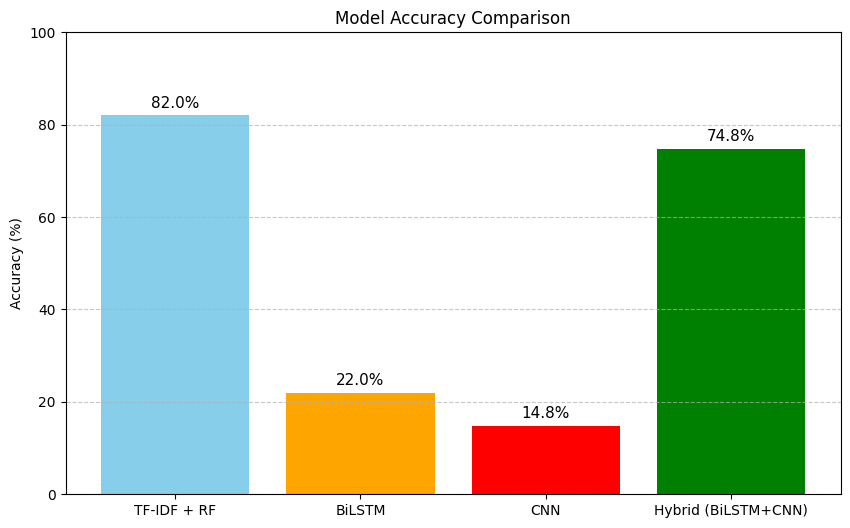

In [ ]:
import matplotlib.pyplot as plt

models = ['TF-IDF + RF', 'BiLSTM', 'CNN', 'Hybrid (BiLSTM+CNN)']
accuracy = [82, 22, 14.8, 74.8]

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=['skyblue', 'orange', 'red', 'green'])
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

plt.show()


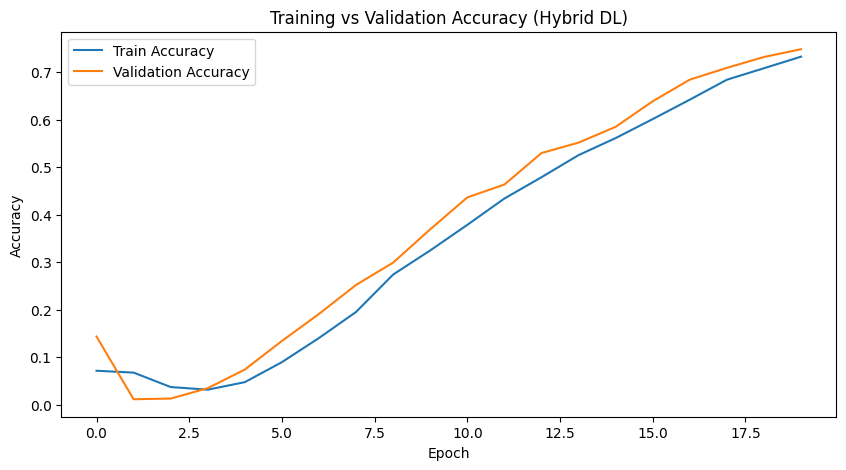

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy (Hybrid DL)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


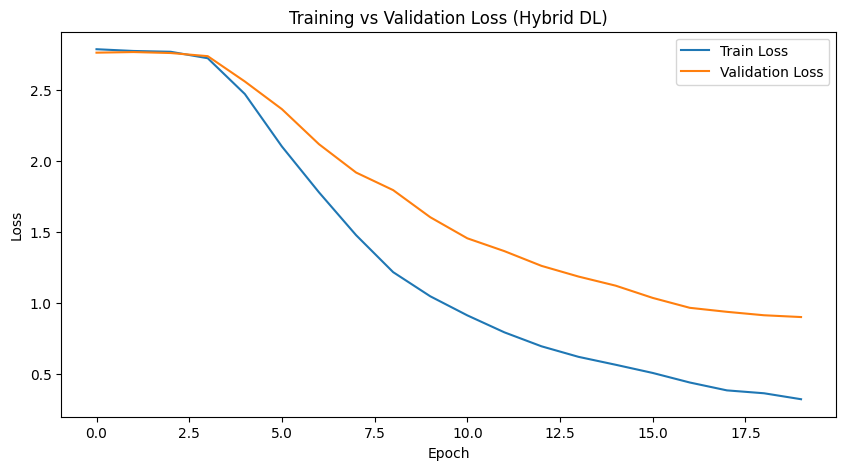

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (Hybrid DL)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step


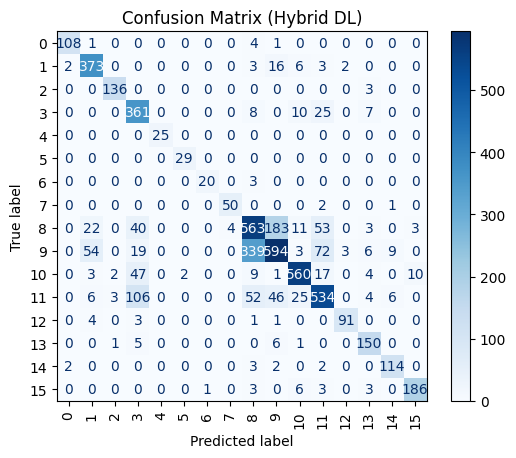

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix (Hybrid DL)')
plt.show()


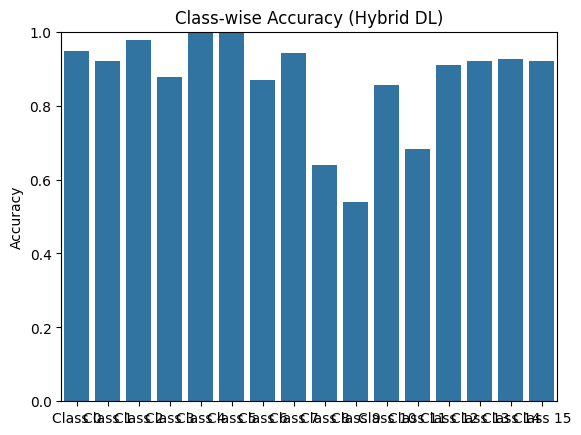

In [ ]:
import seaborn as sns

class_acc = cm.diagonal()/cm.sum(axis=1)
sns.barplot(x=[f'Class {i}' for i in range(len(class_acc))], y=class_acc)
plt.ylabel('Accuracy')
plt.title('Class-wise Accuracy (Hybrid DL)')
plt.ylim(0,1)
plt.show()


In [ ]:
from sklearn.metrics import classification_report
import numpy as np
# DL model predictions (one-hot / softmax output)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # convert to class index
report = classification_report(y_test, y_pred, digits=4)
print(report)


163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step
              precision    recall  f1-score   support

           0     0.9643    0.9474    0.9558       114
           1     0.8056    0.9210    0.8594       405
           2     0.9577    0.9784    0.9680       139
           3     0.6213    0.8783    0.7278       411
           4     1.0000    1.0000    1.0000        25
           5     0.9355    1.0000    0.9667        29
           6     0.9524    0.8696    0.9091        23
           7     0.9259    0.9434    0.9346        53
           8     0.5698    0.6383    0.6021       882
           9     0.6988    0.5405    0.6095      1099
          10     0.9003    0.8550    0.8771       655
          11     0.7511    0.6829    0.7153       782
          12     0.9479    0.9100    0.9286       100
          13     0.8333    0.9202    0.8746       163
          14     0.8769    0.9268    0.9012       123
          15     0.9347    0.9208    0.9277       202

    accuracy                         0

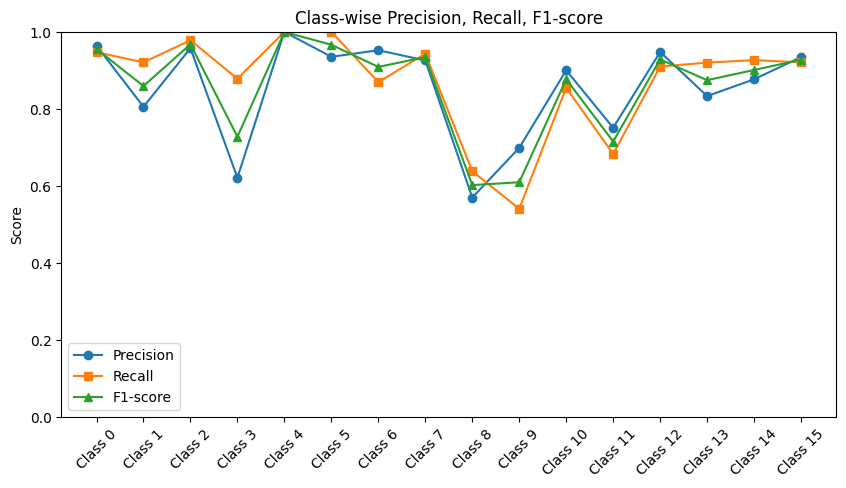

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

plt.figure(figsize=(10,5))
plt.plot(range(len(precision)), precision, marker='o', label='Precision')
plt.plot(range(len(recall)), recall, marker='s', label='Recall')
plt.plot(range(len(f1)), f1, marker='^', label='F1-score')
plt.xticks(range(len(precision)), [f'Class {i}' for i in range(len(precision))], rotation=45)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('Class-wise Precision, Recall, F1-score')
plt.legend()
plt.show()


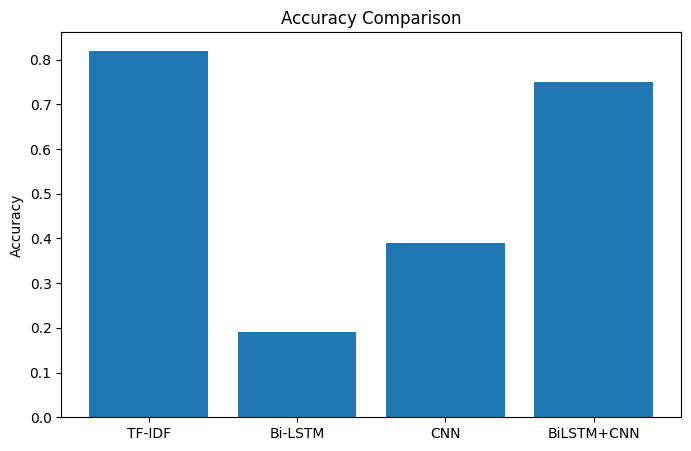

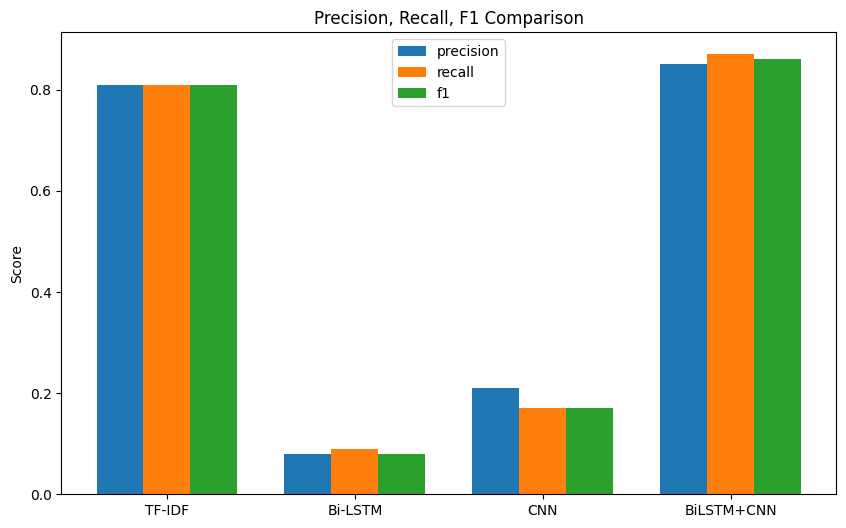

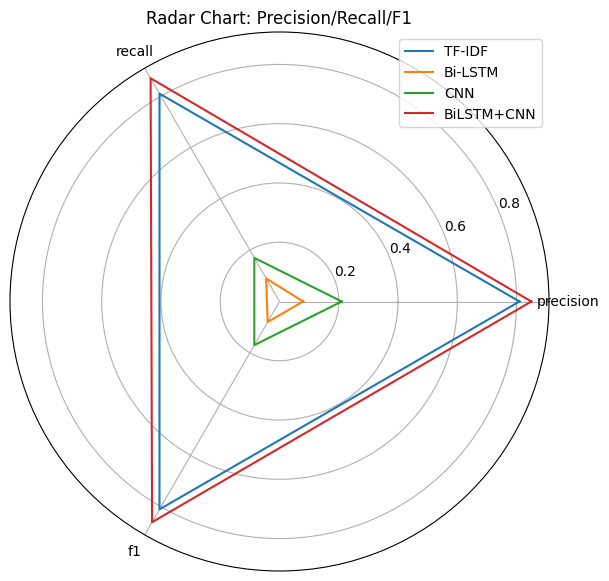

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Tumhare results dal do (macro ya weighted avg wale values use karo)
results = {
    "TF-IDF": {"accuracy": 0.82, "precision": 0.81, "recall": 0.81, "f1": 0.81},
    "Bi-LSTM": {"accuracy": 0.19, "precision": 0.08, "recall": 0.09, "f1": 0.08},
    "CNN": {"accuracy": 0.39, "precision": 0.21, "recall": 0.17, "f1": 0.17},
    "BiLSTM+CNN": {"accuracy": 0.75, "precision": 0.85, "recall": 0.87, "f1": 0.86}
}

# Bar Chart - Accuracy
plt.figure(figsize=(8,5))
plt.bar(results.keys(), [m["accuracy"] for m in results.values()])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Bar Chart - Precision/Recall/F1
metrics = ["precision", "recall", "f1"]
x = np.arange(len(results))
width = 0.25

plt.figure(figsize=(10,6))
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, [m[metric] for m in results.values()], width, label=metric)

plt.xticks(x + width, results.keys())
plt.title("Precision, Recall, F1 Comparison")
plt.ylabel("Score")
plt.legend()
plt.show()

# Radar Chart
labels = list(results.keys())
metrics = ["precision", "recall", "f1"]
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
for model, vals in results.items():
    scores = [vals[m] for m in metrics]
    scores += scores[:1]
    plt.polar(angles, scores, label=model)

plt.xticks(angles[:-1], metrics)
plt.title("Radar Chart: Precision/Recall/F1")
plt.legend()
plt.show()


**Performance comparison of baseline and deep learning model**

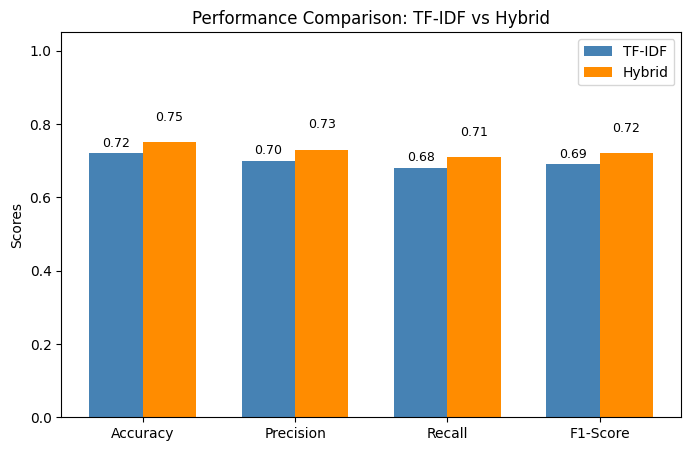

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example metrics (replace with your real values)
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
tfidf_scores = [0.72, 0.70, 0.68, 0.69]
hybrid_scores = [0.75, 0.73, 0.71, 0.72]

x = np.arange(len(metrics))  # metric positions
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - width/2, tfidf_scores, width, label="TF-IDF", color="steelblue")
bars2 = ax.bar(x + width/2, hybrid_scores, width, label="Hybrid", color="darkorange")

# Function to add labels above bars
def add_labels(bars, offset):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            h + offset,
            f"{h:.2f}",
            ha='center', va='bottom', fontsize=9
        )

# Add labels with different offsets to avoid overlap
add_labels(bars1, offset=0.01)   # TF-IDF labels
add_labels(bars2, offset=0.05)   # Hybrid labels (higher)

# Labels and formatting
ax.set_ylabel("Scores")
ax.set_title("Performance Comparison: TF-IDF vs Hybrid")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.ylim(0, 1.05)  # y-axis range

plt.show()


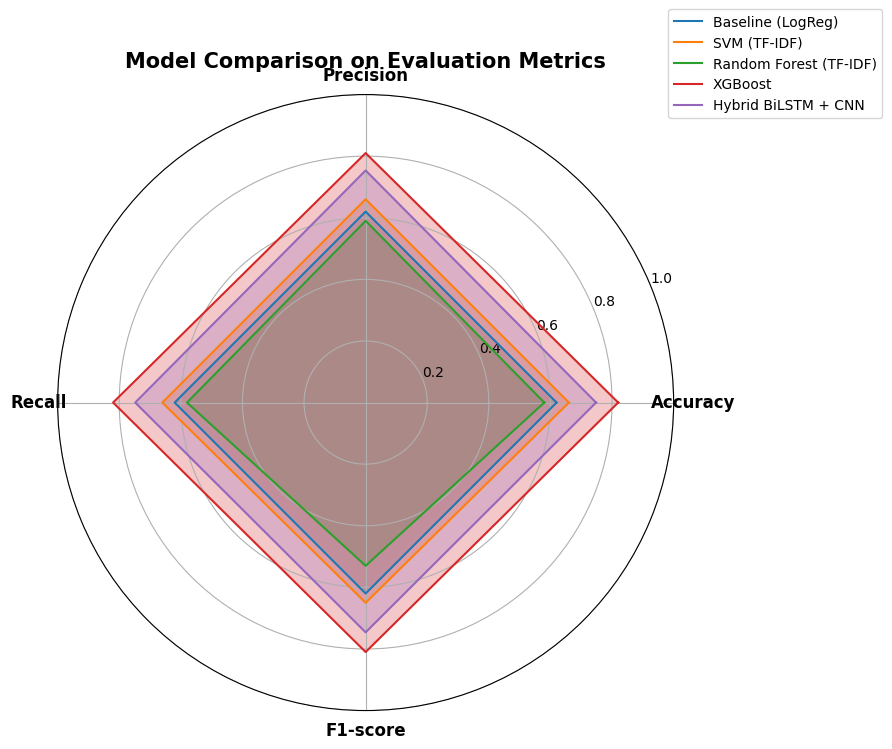

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models and their metrics
models = [
    "Baseline (LogReg)",
    "SVM (TF-IDF)",
    "Random Forest (TF-IDF)",
    "XGBoost",
    "Hybrid BiLSTM + CNN"
]

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

# Scores from your table
scores = [
    [0.62, 0.62, 0.62, 0.62],       # Baseline
    [0.66, 0.66, 0.66, 0.65],       # SVM
    [0.58, 0.59, 0.58, 0.53],       # Random Forest
    [0.82, 0.81, 0.82, 0.81],       # XGBoost
    [0.7481, 0.7536, 0.7481, 0.7460]  # Hybrid BiLSTM + CNN
]

# Radar chart setup
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # close loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, score in enumerate(scores):
    values = score + score[:1]  # close loop
    ax.plot(angles, values, label=models[i])
    ax.fill(angles, values, alpha=0.25)

# Labels adjustment
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12, weight="bold")

# Rotate labels outward so overlap na ho
for label, angle in zip(ax.get_xticklabels(), angles):
    label.set_rotation(np.degrees(angle))
    label.set_horizontalalignment("center")

ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)
ax.set_ylim(0, 1)

plt.title("Model Comparison on Evaluation Metrics", size=15, weight="bold", pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.show()
